--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB
None

--- Data Head ---
   credit.policy     

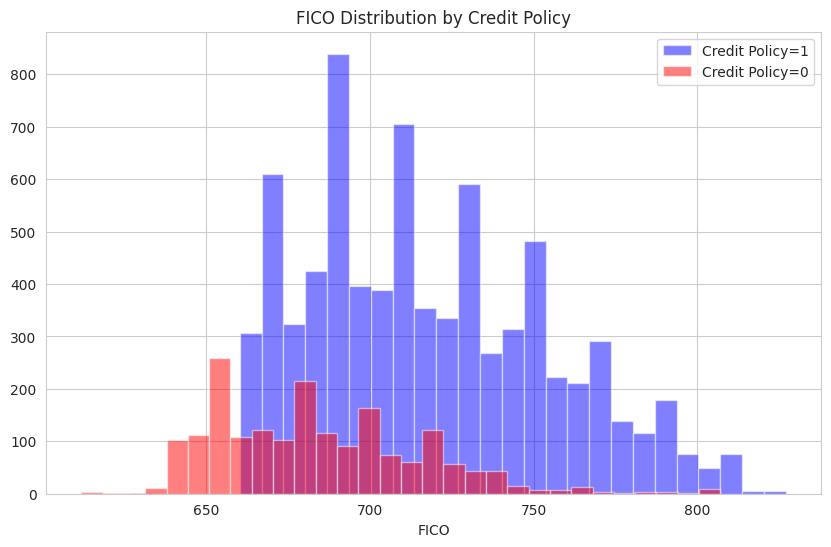

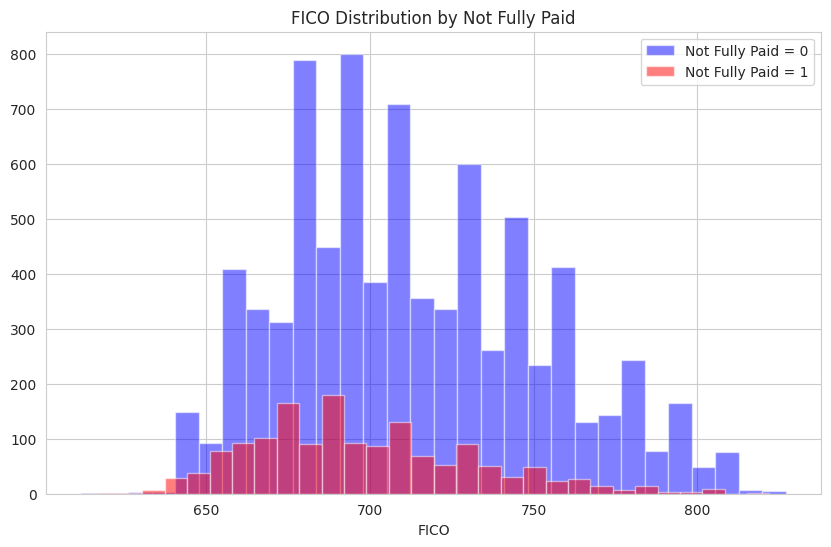

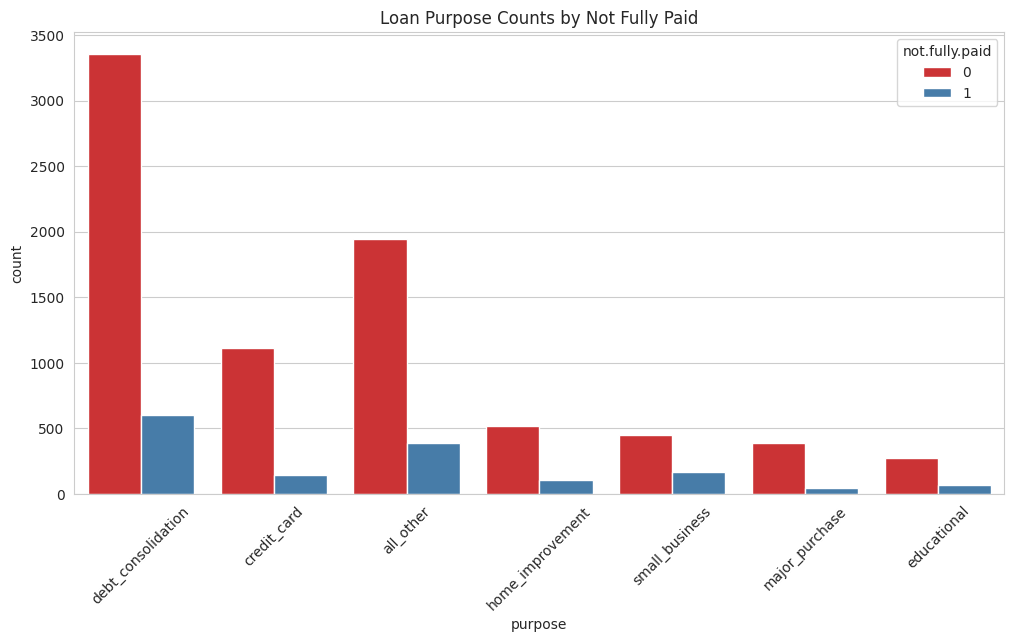

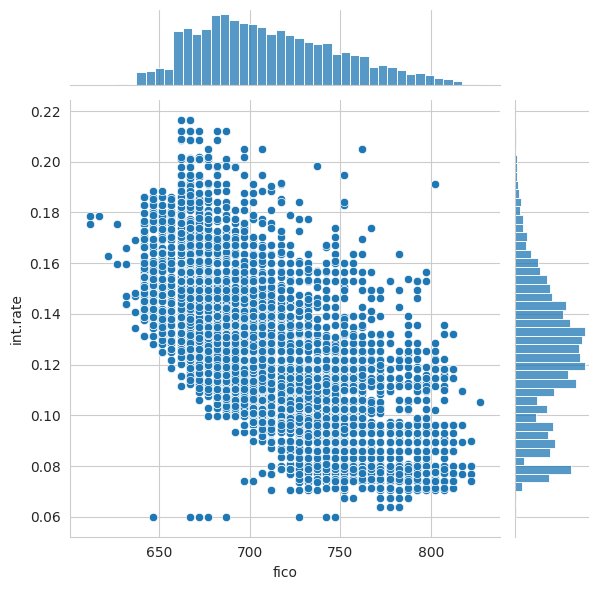

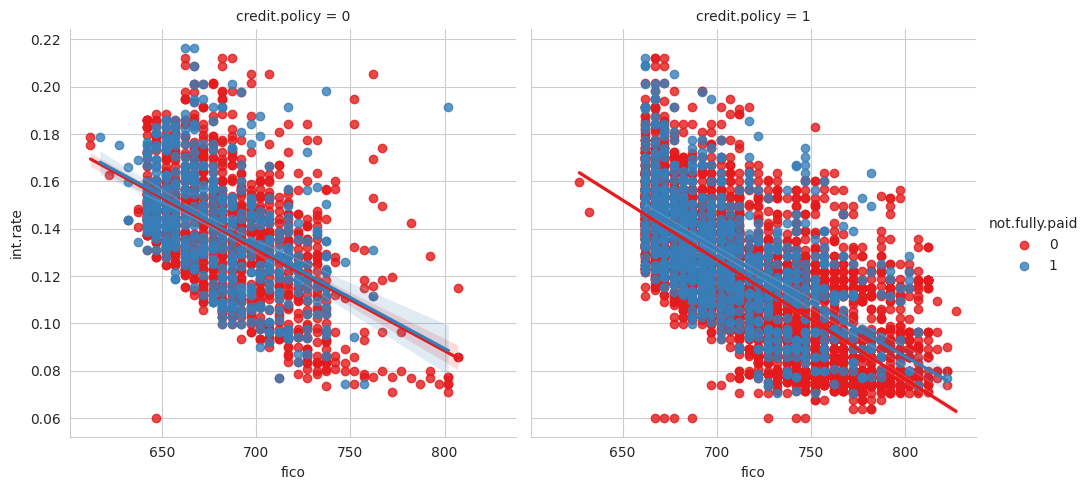


--- Decision Tree Results ---
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      2431
           1       0.20      0.24      0.22       443

    accuracy                           0.73      2874
   macro avg       0.53      0.53      0.53      2874
weighted avg       0.76      0.73      0.74      2874

Confusion Matrix:
[[2003  428]
 [ 336  107]]

--- Random Forest Results ---
Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2431
           1       0.54      0.02      0.03       443

    accuracy                           0.85      2874
   macro avg       0.69      0.51      0.47      2874
weighted avg       0.80      0.85      0.78      2874

Confusion Matrix:
[[2425    6]
 [ 436    7]]


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

%matplotlib inline
sns.set_style('whitegrid')

loans = pd.read_csv('loan_data.csv')

print("--- Data Info ---")
print(loans.info())
print("\n--- Data Head ---")
print(loans.head())
print("\n--- Data Description ---")
print(loans.describe())

plt.figure(figsize=(10,6))
loans[loans['credit.policy']==1]['fico'].hist(alpha=0.5, color='blue', bins=30, label='Credit Policy=1')
loans[loans['credit.policy']==0]['fico'].hist(alpha=0.5, color='red', bins=30, label='Credit Policy=0')
plt.legend()
plt.xlabel('FICO')
plt.title('FICO Distribution by Credit Policy')
plt.show()

plt.figure(figsize=(10,6))
loans[loans['not.fully.paid']==0]['fico'].hist(alpha=0.5, color='blue', bins=30, label='Not Fully Paid = 0')
loans[loans['not.fully.paid']==1]['fico'].hist(alpha=0.5, color='red', bins=30, label='Not Fully Paid = 1')
plt.legend()
plt.xlabel('FICO')
plt.title('FICO Distribution by Not Fully Paid')
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(x='purpose', hue='not.fully.paid', data=loans, palette='Set1')
plt.title('Loan Purpose Counts by Not Fully Paid')
plt.xticks(rotation=45)
plt.show()

sns.jointplot(x='fico', y='int.rate', data=loans, kind='scatter')
plt.show()

sns.lmplot(x='fico', y='int.rate', data=loans, hue='not.fully.paid', col='credit.policy', palette='Set1')
plt.show()

cat_feats = ['purpose']
final_data = pd.get_dummies(loans, columns=cat_feats, drop_first=True)

X = final_data.drop('not.fully.paid', axis=1)
y = final_data['not.fully.paid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

dtree = DecisionTreeClassifier()
dtree.fit(X_train, y_train)

predictions_dtree = dtree.predict(X_test)

print("\n--- Decision Tree Results ---")
print("Classification Report:")
print(classification_report(y_test, predictions_dtree))
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions_dtree))

rfc = RandomForestClassifier(n_estimators=600)
rfc.fit(X_train, y_train)

predictions_rfc = rfc.predict(X_test)

print("\n--- Random Forest Results ---")
print("Classification Report:")
print(classification_report(y_test, predictions_rfc))
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions_rfc))